# 코랩 my drive 연동

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# google api key

# 패키지 설치

In [3]:
!pip install langgraph
!pip install langchain
!pip install langchain-experimental
!pip install google-generativeai
!pip install langchain langchain-openai
!pip install python-dotenv langchain_openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.1/210.1 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 76.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 63.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.0/65.0 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 6.1 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.33.0 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.7/506.7 kB 24.9 MB/s eta 0:00:00
  Attempting u

In [4]:
pip install "pydantic==2.9.2"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.4/149.4 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 434.9/434.9 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 37.7 MB/s eta 0:00:00
  Attempting uninstall: pydantic-core
    Found existing installation: pydantic_core 2.41.4
    Uninstalling pydantic_core-2.41.4:
      Successfully uninstalled pydantic_core-2.41.4
  Attempting uninstall: pydantic
    Found existing installation: pydantic 2.12.3
    Uninstalling pydantic-2.12.3:
      Successfully uninstalled pydantic-2.12.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.27.1 requires pydantic<3.0.0,>=2.12.0, but you have pydantic 2.9.2 which is incompatible.
mcp 1.26.0 requires pydantic<3.0.0,>=2.11.0, but you have pydantic 2.9.2 which is incompatible.


In [5]:
!pip show langgraph

Name: langgraph
Version: 1.1.2
Summary: Building stateful, multi-actor applications with LLMs
Home-page: https://docs.langchain.com/oss/python/langgraph/overview
Author: 
Author-email: 
License: 
Location: /usr/local/lib/python3.12/dist-packages
Requires: langchain-core, langgraph-checkpoint, langgraph-prebuilt, langgraph-sdk, pydantic, xxhash
Required-by: langchain


버전 수정 후 다시 세션 시작해야 함

## 검색형 챗봇

In [3]:
# 필요한 라이브러리 불러오기
import pandas as pd
import numpy as np
from sqlalchemy import create_engine, text
from typing import Optional, List
import sqlalchemy.exc
from sqlalchemy.exc import SQLAlchemyError
import google.generativeai as genai
from langchain_experimental.sql import SQLDatabaseChain
# from langchain.sql_database import SQLDatabase
from langchain_community.utilities import SQLDatabase
# from langchain.llms.base import LLM
from langchain_core.language_models.llms import LLM
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
import re
import ast
from datetime import datetime
from langchain_core.runnables import RunnableLambda
import os
import glob

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


# 데이터 확인

In [4]:
mct_data = pd.read_csv("/content/drive/MyDrive/챗봇_관광데이터/JEJU_MCT_DATA_v2.csv", encoding='cp949')

In [5]:
# 파일 경로 패턴 설정 (예: 2023년 1~12월)
file_paths = sorted(glob.glob("/content/drive/MyDrive/챗봇_관광데이터/JT_MT_ACCTO_TRRSRT_SCCNT_LIST_2023*.csv"))

# 월 코드 매핑
month_map = {
    '01': 'JAN', '02': 'FEB', '03': 'MAR', '04': 'APR',
    '05': 'MAY', '06': 'JUN', '07': 'JULY', '08': 'AUG',
    '09': 'SEP', '10': 'OCT', '11': 'NOV', '12': 'DEC'
}

merged_mt = None

for path in file_paths:
    df = pd.read_csv(path, encoding="utf-8-sig")

    # '202303' → '03' → 'MAR'
    mm = path[-10:-4][4:]
    col = f"{month_map[mm]}_VIEWS_CO"

    # 필요한 컬럼만 유지
    keep_cols = ['CL_CD', 'CL_NM', 'AREA_NM', 'ADDR', 'BASE_YEAR', col]
    df = df[keep_cols].copy()

    # 컬럼명을 통일해서 병합할 수 있도록 변경
    df = df.rename(columns={col: f"{col}"})

    # 첫 달이면 기준 데이터프레임 생성
    if merged_mt is None:
        merged_mt = df
    else:
        # 기존 데이터프레임과 병합 (중복 행 병합)
        merged_mt = pd.merge(merged_mt, df, on=['CL_CD', 'CL_NM', 'AREA_NM', 'ADDR', 'BASE_YEAR'], how='outer')

# 확인
print(merged_mt.head())

  CL_CD CL_NM         AREA_NM                       ADDR  BASE_YEAR  \
0    c1   관광지  (주)제주해양레저 투명카약   제주특별자치도 제주시 애월읍 애월로1길 22       2023   
1    c1   관광지     1100고지(휴게소)    제주특별자치도 서귀포시 1100로 1555       2023   
2    c1   관광지        1100고지습지     제주특별자치도 서귀포시 색달동 산 1-2       2023   
3    c1   관광지          1112도로  제주특별자치도 제주시 명림로 584 (봉개동)       2023   
4    c1   관광지        4·3해원방사탑         제주특별자치도 제주시 신산로 82       2023   

   JAN_VIEWS_CO  FEB_VIEWS_CO  MAR_VIEWS_CO  APR_VIEWS_CO  MAY_VIEWS_CO  \
0          68.0          55.0          83.0          83.0          82.0   
1        1587.0         699.0         481.0         450.0         412.0   
2        4075.0        1551.0         471.0         472.0         426.0   
3          79.0          45.0          49.0          39.0          36.0   
4          48.0          27.0          53.0          61.0          50.0   

   JUN_VIEWS_CO  JULY_VIEWS_CO  AUG_VIEWS_CO  SEP_VIEWS_CO  OCT_VIEWS_CO  \
0          69.0           79.0          48.0  

In [6]:
merged_mt[merged_mt['AREA_NM'] == '브랭섬홀아시아 아이스링크']

,CL_CD,CL_NM,AREA_NM,ADDR,BASE_YEAR,JAN_VIEWS_CO,FEB_VIEWS_CO,MAR_VIEWS_CO,APR_VIEWS_CO,MAY_VIEWS_CO,JUN_VIEWS_CO,JULY_VIEWS_CO,AUG_VIEWS_CO,SEP_VIEWS_CO,OCT_VIEWS_CO,NOV_VIEWS_CO,DEC_VIEWS_CO
459,c1,관광지,브랭섬홀아시아 아이스링크,제주특별자치도 서귀포시 대정읍 글로벌에듀로 234(3번게이트),2023,110.0,215.0,113.0,106.0,116.0,107.0,94.0,61.0,54.0,60.0,59.0,87.0


In [7]:
# 파일 경로 패턴 설정
file_paths = sorted(glob.glob("/content/drive/MyDrive/챗봇_관광데이터/JT_WKDAY_ACCTO_TRRSRT_SCCNT_LIST_2023*.csv"))

df_list = []

for path in file_paths:
    df = pd.read_csv(path, encoding="utf-8-sig")

    # '202301' ~ '202312' → '2023-01' 형식으로 추출
    yyyymm = path[-10:-4]
    df['월'] = f"{yyyymm[:4]}-{yyyymm[4:]}"  # 예: 2023-01

    df_list.append(df)

# 병합 (row-wise)
merged_wkday = pd.concat(df_list, ignore_index=True)

# 확인
print(merged_wkday.columns)
print(merged_wkday[['CL_NM', '월', 'MON_VIEWS_CO', 'SUN_VIEWS_CO']].head())


Index(['CL_CD', 'CL_NM', 'AREA_NM', 'ADDR', 'BASE_YEAR', 'BASE_MT',
       'ALL_TOTAL_CO', 'MON_VIEWS_CO', 'TUES_VIEWS_CO', 'WED_VIEWS_CO',
       'THUR_VIEWS_CO', 'FRI_VIEWS_CO', 'SAT_VIEWS_CO', 'SUN_VIEWS_CO', '월'],
      dtype='object')
  CL_NM        월  MON_VIEWS_CO  SUN_VIEWS_CO
0   관광지  2023-01          15.0          23.0
1   관광지  2023-01          11.0          13.0
2   관광지  2023-01         313.0         250.0
3   관광지  2023-01         662.0         724.0
4   관광지  2023-01          17.0          11.0


In [8]:
merged_wkday[merged_wkday['AREA_NM'] == '브랭섬홀아시아 아이스링크']

,CL_CD,CL_NM,AREA_NM,ADDR,BASE_YEAR,BASE_MT,ALL_TOTAL_CO,MON_VIEWS_CO,TUES_VIEWS_CO,WED_VIEWS_CO,THUR_VIEWS_CO,FRI_VIEWS_CO,SAT_VIEWS_CO,SUN_VIEWS_CO,월
0,c1,관광지,브랭섬홀아시아 아이스링크,제주특별자치도 서귀포시 대정읍 글로벌에듀로 234(3번게이트),2023,1,110,15.0,12.0,14.0,16.0,24.0,6.0,23.0,2023-01
3982,c1,관광지,브랭섬홀아시아 아이스링크,제주특별자치도 서귀포시 대정읍 글로벌에듀로 234(3번게이트),2023,2,215,30.0,30.0,23.0,33.0,36.0,40.0,23.0,2023-02
7817,c1,관광지,브랭섬홀아시아 아이스링크,제주특별자치도 서귀포시 대정읍 글로벌에듀로 234(3번게이트),2023,3,113,18.0,10.0,18.0,14.0,17.0,20.0,16.0,2023-03
11661,c1,관광지,브랭섬홀아시아 아이스링크,제주특별자치도 서귀포시 대정읍 글로벌에듀로 234(3번게이트),2023,4,106,14.0,7.0,15.0,19.0,13.0,24.0,14.0,2023-04
15512,c1,관광지,브랭섬홀아시아 아이스링크,제주특별자치도 서귀포시 대정읍 글로벌에듀로 234(3번게이트),2023,5,116,19.0,18.0,22.0,15.0,16.0,12.0,14.0,2023-05
19514,c1,관광지,브랭섬홀아시아 아이스링크,제주특별자치도 서귀포시 대정읍 글로벌에듀로 234(3번게이트),2023,6,107,12.0,20.0,14.0,20.0,18.0,8.0,15.0,2023-06
23891,c1,관광지,브랭섬홀아시아 아이스링크,제주특별자치도 서귀포시 대정읍 글로벌에듀로 234(3번게이트),2023,7,94,19.0,14.0,15.0,8.0,13.0,9.0,16.0,2023-07
28453,c1,관광지,브랭섬홀아시아 아이스링크,제주특별자치도 서귀포시 대정읍 글로벌에듀로 234(3번게이트),2023,8,61,13.0,8.0,11.0,10.0,7.0,6.0,6.0,2023-08
32983,c1,관광지,브랭섬홀아시아 아이스링크,제주특별자치도 서귀포시 대정읍 글로벌에듀로 234(3번게이트),2023,9,54,8.0,10.0,6.0,4.0,9.0,8.0,9.0,2023-09
37508,c1,관광지,브랭섬홀아시아 아이스링크,제주특별자치도 서귀포시 대정읍 글로벌에듀로 234(3번게이트),2023,10,60,15.0,12.0,5.0,10.0,2.0,6.0,10.0,2023-10


In [9]:
mct_data

,YM,MCT_NM,OP_YMD,MCT_TYPE,ADDR,UE_CNT_GRP,UE_AMT_GRP,UE_AMT_PER_TRSN_GRP,MON_UE_CNT_RAT,TUE_UE_CNT_RAT,...,HR_18_22_UE_CNT_RAT,HR_23_4_UE_CNT_RAT,LOCAL_UE_CNT_RAT,RC_M12_MAL_CUS_CNT_RAT,RC_M12_FME_CUS_CNT_RAT,RC_M12_AGE_UND_20_CUS_CNT_RAT,RC_M12_AGE_30_CUS_CNT_RAT,RC_M12_AGE_40_CUS_CNT_RAT,RC_M12_AGE_50_CUS_CNT_RAT,RC_M12_AGE_OVR_60_CUS_CNT_RAT
0,202301,통큰돼지,20110701,가정식,제주 제주시 용담이동 2682-9번지 통큰돼지,5_75~90%,4_50~75%,3_25~50%,0.161290,0.032258,...,0.838710,0.000000,0.707763,0.610,0.390,0.103,0.124,0.245,0.387,0.142
1,202301,해변,20050407,단품요리 전문,제주 제주시 애월읍 애월리 410-6번지,3_25~50%,2_10~25%,2_10~25%,0.090909,0.121212,...,0.560606,0.000000,0.230928,0.542,0.458,0.221,0.201,0.195,0.244,0.139
2,202301,한그릇,20120919,단품요리 전문,제주 서귀포시 색달동 2315-1번지 한그릇,3_25~50%,3_25~50%,4_50~75%,0.224719,0.112360,...,0.000000,0.000000,0.347059,0.529,0.471,0.138,0.309,0.342,0.164,0.047
3,202301,협재해녀의집,20130627,가정식,제주 제주시 한림읍 협재리 1459-2번지,3_25~50%,3_25~50%,4_50~75%,0.000000,0.271739,...,0.152174,0.000000,0.016096,0.484,0.516,0.323,0.321,0.209,0.109,0.039
4,202301,까망꼬숑,20220826,단품요리 전문,제주 제주시 노형동 3784-12번지 1층,5_75~90%,3_25~50%,2_10~25%,0.272727,0.121212,...,0.727273,0.090909,0.264463,0.513,0.487,0.412,0.311,0.176,0.076,0.025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67859,202312,미나리,20230630,가정식,제주 제주시 연동 291-24번지 연동,3_25~50%,2_10~25%,4_50~75%,0.192000,0.216000,...,0.216000,0.000000,0.724662,0.546,0.454,0.091,0.261,0.313,0.241,0.094
67860,202312,종달리엔심야식당,20210513,가정식,제주 제주시 구좌읍 종달리 1935-1번지 1층,4_50~75%,4_50~75%,3_25~50%,0.150000,0.150000,...,1.000000,0.000000,0.013807,0.251,0.749,0.504,0.351,0.077,0.052,0.017
67861,202312,경일낙지,20020112,단품요리 전문,제주 제주시 노형동 1291-3번지,2_10~25%,2_10~25%,4_50~75%,0.179310,0.241379,...,0.000000,0.000000,0.825083,0.424,0.576,0.054,0.218,0.379,0.263,0.086
67862,202312,흑돼지가있는풍경,20040109,가정식,제주 제주시 노형동 668번지,5_75~90%,2_10~25%,1_상위 10% 이하,0.066667,0.000000,...,0.733333,0.000000,0.196682,0.574,0.426,0.109,0.188,0.213,0.305,0.185


In [10]:
import json

with open("/content/drive/MyDrive/챗봇 만들기_제주관광데이터/혜원/json/cost_similarity.json", encoding="utf-8") as f:
    cost_similarity = json.load(f)

with open("/content/drive/MyDrive/챗봇 만들기_제주관광데이터/혜원/json/data_info.json", encoding="utf-8") as f:
    data_info = json.load(f)

with open("/content/drive/MyDrive/챗봇 만들기_제주관광데이터/혜원/json/jeju_region.json", encoding="utf-8") as f:
    jeju_region = json.load(f)

with open("/content/drive/MyDrive/챗봇 만들기_제주관광데이터/혜원/json/month.json", encoding="utf-8") as f:
    month = json.load(f)

with open("/content/drive/MyDrive/챗봇 만들기_제주관광데이터/혜원/json/most_hot_scoring.json", encoding="utf-8") as f:
    most_hot_scoring = json.load(f)

with open("/content/drive/MyDrive/챗봇 만들기_제주관광데이터/혜원/json/sex_age.json", encoding="utf-8") as f:
    sex_age = json.load(f)

with open("/content/drive/MyDrive/챗봇 만들기_제주관광데이터/혜원/json/time.json", encoding="utf-8") as f:
    time_route_score = json.load(f)

with open("/content/drive/MyDrive/챗봇 만들기_제주관광데이터/혜원/json/time_route_score.json", encoding="utf-8") as f:
    time = json.load(f)

# 여러 파일 각각 SQL 테이블로 저장

In [11]:
# SQLite 데이터베이스 엔진 생성
# 데이터베이스 연결하기
# SQLite DB 연결
engine = create_engine("sqlite:///jeju_recommendation.db")

# 데이터베이스에 테이블 저장
# DataFrame에 저장된 레코드를 SQL 데이터베이스에 넣을 수 있음
merged_wkday.to_sql("merged_wkday", engine, if_exists="replace", index=False)
merged_mt.to_sql("merged_mt", engine, if_exists="replace", index=False)
mct_data.to_sql("jeju_mct_data", engine, if_exists="replace", index=False)

67864

### 코드

In [ ]:
# -*- coding: utf-8 -*-
import re, ast

# ====== 사용자 제공 동의어 사전 ======
synonym_dict = {
    "가정식": ["집밥", "한식당", "홈메이드", "백반집", "백반"],
    "단품요리 전문": ["일품요리", "단품식사", "간단요리"],
    "커피": ["카페", "에스프레소", "커피숍", "디저트"],
    "베이커리": ["빵집", "제과점", "카페", "커피숍", "디저트"],
    "일식": ["스시", "사시미", "일본식당", "이자카야", "카츠", "돈까스", "라멘", "마제소바"],
    "치킨": ["후라이드", "양념치킨", "치킨집"],
    "중식": ["짜장면", "짬뽕", "중화요리"],
    "분식": ["떡볶이", "김밥", "라면"],
    "햄버거": ["버거", "패스트푸드", "수제버거"],
    "양식": ["파스타", "리조또", "스테이크하우스", "레스토랑"],
    "맥주/요리주점": ["펍", "술집", "호프집"],
    "아이스크림/빙수": ["디저트카페", "젤라또", "빙수전문점", "디저트"],
    "피자": ["피자집", "이탈리안피자", "패스트푸드"],
    "샌드위치/토스트": ["브런치카페", "토스트집", "샌드위치샵"],
    "차": ["티", "전통차", "티하우스", "카페", "커피숍", "찻집", "디저트"],
    "꼬치구이": ["야키토리", "꼬치집", "포장마차", "이자카야"],
    "기타세계요리": ["퓨전요리", "글로벌레스토랑", "이색음식"],
    "구내식당/푸드코트": ["사내식당", "푸드홀", "단체식당"],
    "떡/한과": ["전통떡집", "한과전문점", "떡카페", "카페", "디저트"],
    "도시락": ["편의점도시락", "점심도시락", "배달도시락"],
    "도너츠": ["도넛", "도넛카페", "스낵샵", "카페", "커피숍", "디저트"],
    "주스": ["스무디", "주스바", "과일주스", "카페", "커피숍"],
    "동남아/인도음식": ["타이음식", "인도커리", "베트남쌀국수"],
    "패밀리 레스토랑": ["외식레스토랑", "패밀리다이닝", "가족식당", "레스토랑"],
    "기사식당": ["운전기사식당", "현장식당", "한식백반"],
    "야식": ["늦은밤음식", "배달야식", "야식전문점", "닭발"],
    "스테이크": ["스테이크하우스", "소고기스테이크", "양식당", "레스토랑"],
    "포장마차": ["길거리음식", "노점", "호프집", "술집"],
    "부페": ["뷔페", "샐러드바", "무한리필", "레스토랑"],
    "민속주점": ["전통술집", "한식주점", "막걸리집", "술집"]
}

explain_prompt = '''
- 2023년 1월 ~ 2023년 12월 제주지역 가맹점 중 요식관련 업종이면서 월별 업종별 매출 상위 30% 가맹점 데이터

    {data_info} json 데이터를 이용하시오.

    제약 조건:
    - "MCT_TYPE"은 여러 개의 값이 있을 수 있으며, IN 연산자를 사용해야 합니다.
    - 서브쿼리를 사용할 필요 없이 직접 조회하는 방식으로 작성하세요.
    - 가맹점명만 select 할 수 있게 작성하세요.
    - question을 바탕으로 limit 여부 결정하세요.

    위 정보를 바탕으로 적절한 SQL 쿼리를 생성해 주세요.
    '''

# ====== Google API 키 설정 ======
genai.configure(api_key=GOOGLE_API_KEY)

# ====== 공통 유틸 ======
def clean_sql(raw: str) -> str:
    s = (raw or "").strip()
    s = re.sub(r"^\s*SQLQuery:\s*", "", s, flags=re.IGNORECASE)
    s = re.sub(r"^```[a-zA-Z]*\s*", "", s)
    s = re.sub(r"\s*```$", "", s)
    s = s.replace("```", "")
    m = re.search(r"(?is)\bselect\b[\s\S]+?(?=(?:;\s*|\n{2,}|SQLResult:|Answer:|\Z))", s)
    if m:
        sql = m.group(0).strip()
        return sql if sql.endswith(";") else sql
    m2 = re.search(r"(?is)\bselect\b[\s\S]+?;", s)
    return m2.group(0).strip() if m2 else ""

def _safe_extract_sql(text: str) -> str:
    if not isinstance(text, str):
        return ""
    m = re.search(r"```(?:sql|sqlite)\s+([\s\S]+?)```", text, flags=re.IGNORECASE)
    if not m:
        m = re.search(r"```\s*([\s\S]+?)```", text, flags=re.IGNORECASE)
    if m:
        sql = m.group(1).strip()
        if sql.lower().startswith("select"):
            return sql
    m = re.search(r"SQLQuery:\s*([\s\S]+?)(?:\n[A-Z][A-Za-z]+:|\Z)", text)
    if m:
        return m.group(1).strip()
    m = re.search(r"(?is)\bselect\b[\s\S]+?(?=(?:;\s*|\n{2,}|SQLResult:|Answer:|\Z))", text)
    if m:
        sql = m.group(0).strip()
        if len(sql) >= 60 and " from " in sql.lower():
            return sql
    return text.strip()

# ====== Gemini LLM 래퍼 ======
class GeminiLLM(LLM):
    model_name: str = "models/gemini-2.5-flash-lite"
    @property
    def _llm_type(self) -> str:
        return "gemini"
    def _call(self, prompt: str, stop: Optional[List[str]] = None) -> str:
        try:
            model = genai.GenerativeModel(self.model_name)
            response = model.generate_content(
                prompt,
                generation_config={"temperature": 0.2, "max_output_tokens": 1024},
            )
            text = getattr(response, "text", None)
            if not text and hasattr(response, "candidates") and response.candidates:
                try:
                    parts = getattr(response.candidates[0], "content", None)
                    text = getattr(parts, "text", None) if parts else None
                except Exception:
                    text = None
            if not isinstance(text, str):
                text = ""
            sql_or_text = _safe_extract_sql(text)
            return sql_or_text or ""
        except Exception:
            return ""

# ====== 상태 타입 ======
class InformationDict(TypedDict, total=False):
    sex: str
    age: str
    date: str
    month: Optional[int]
    time: str
    recent_months: List[int]

class MyState(TypedDict):
    info_sex: str
    question: str
    information_dict: InformationDict
    classificate: str
    answer: str
    category: str
    mct_types: List[str]
    prompt: str
    query: str
    result: str
    db_chain_instance: Optional[SQLDatabaseChain]
    unknown_count : int
    location: str
    info_age: str
    info_date: str
    reference_store: str
    region: str
    query_raw: str

# ====== 입력 ======
def question_input(state: MyState) -> MyState:
    print("🤖 Gemini: 질문을 입력해주세요!")
    q = input("👤 나: ")
    state.update({"question": q})
    return state

# ====== (신규) 필수 정보 LLM 추출 & 재질문 루프 ======
def normalize_sex(s: str) -> str:
    s = (s or "").strip().lower()
    if s in ["남", "남자", "male", "m"]:
        return "남"
    if s in ["여", "여자", "female", "f"]:
        return "여"
    return ""

def normalize_age(a: str) -> str:
    a = (a or "").strip()
    m = re.search(r"\d{1,3}", a)
    return m.group(0) if m else ""

def normalize_date(d: str) -> str:
    d = (d or "").strip()
    if not d:
        return ""
    # 간단 정규화: "7월", "07월", "2025-07-05~2025-07-08", "0705 - 0708" 등 허용
    return d

def llm_extract_needed_info(text: str) -> dict:
    """
    LLM에게서 sex/age/date 추출 및 결측 항목 리스트 생성
    출력은 반드시 JSON(dict) 형태:
    {"sex": "...", "age": "...", "date": "...", "missing": ["sex","age",...]}
    """
    prompt = f"""
아래 문장에서 성별(sex), 나이(age), 여행 날짜 또는 월(date)을 추출해.
모르면 빈 문자열로 두고, 어떤 항목이 비었는지 "missing" 배열에 넣어.

문장: {text}

출력 예시(JSON만):
{{"sex":"여","age":"30","date":"7월","missing":[]}}
또는
{{"sex":"","age":"25","date":"","missing":["sex","date"]}}

주의:
- 반드시 JSON만 출력. 코드블록 금지. 설명 금지.
"""
    model = genai.GenerativeModel("models/gemini-2.5-flash-lite")
    resp = model.generate_content(prompt, generation_config={"temperature":0.0, "max_output_tokens":256})
    raw = getattr(resp, "text", "") or ""
    # JSON만 추출
    m = re.search(r"\{[\s\S]*\}", raw)
    if not m:
        return {"sex":"", "age":"", "date":"", "missing":["sex","age","date"]}
    try:
        data = ast.literal_eval(m.group(0))
    except Exception:
        return {"sex":"", "age":"", "date":"", "missing":["sex","age","date"]}
    # 정규화
    data["sex"]  = normalize_sex(data.get("sex",""))
    data["age"]  = normalize_age(data.get("age",""))
    data["date"] = normalize_date(data.get("date",""))
    missing = []
    if not data["sex"]:  missing.append("sex")
    if not data["age"]:  missing.append("age")
    if not data["date"]: missing.append("date")
    data["missing"] = missing
    return data

def llm_build_followup_question(missing_fields: List[str]) -> str:
    """
    누락 항목들(sex/age/date)에 맞춰 한국어 재질문 문장을 LLM으로 생성.
    """
    labels = {
        "sex": "성별(남/여)",
        "age": "나이(숫자)",
        "date": "여행 날짜 또는 월(예: 0705-0708 또는 7월)"
    }
    need = ", ".join([labels[m] for m in missing_fields])
    base = f"아래 정보를 알려주세요: {need}"
    # 간단하게 deterministic 문장 생성 (LLM 호출 없이도 충분)
    return base

def ensure_required_info(state: MyState) -> MyState:
    """
    1) 초기 질문에서 LLM으로 sex/age/date 추출
    2) 빠진 항목 있으면 재질문 → 사용자 답변 반영 → 다시 추출·병합
    3) 모두 채워질 때까지 반복(최대 3회)
    """
    question = state.get("question","")
    # 1차 추출
    info = llm_extract_needed_info(question)

    # 기존 state 값(있다면)과 병합
    cur_sex  = normalize_sex(state.get("info_sex","")) or info["sex"]
    cur_age  = normalize_age(state.get("info_age","")) or info["age"]
    cur_date = normalize_date(state.get("info_date","")) or info["date"]

    # 루프 (최대 3회)
    tries = 0
    while tries < 3:
        missing = []
        if not cur_sex:  missing.append("sex")
        if not cur_age:  missing.append("age")
        if not cur_date: missing.append("date")

        if not missing:
            break  # 모두 채워짐

        followup = llm_build_followup_question(missing)
        print(f"🤖 Gemini: {followup}")
        ans = input("👤 나: ").strip()

        # 재답변에서 또 추출
        add = llm_extract_needed_info(ans)
        # 병합(기존 비었으면 채움)
        if not cur_sex and add["sex"]:
            cur_sex = add["sex"]
        if not cur_age and add["age"]:
            cur_age = add["age"]
        if not cur_date and add["date"]:
            cur_date = add["date"]

        tries += 1

    # 최종 업데이트
    state.update({
        "info_sex": cur_sex or "",
        "info_age": cur_age or "",
        "info_date": cur_date or ""
    })
    return state

# ====== 질문이 답변 가능한지 분류 ======
def question_unknown(state: MyState) -> MyState:
    user_input = state["question"]
    prompt = f"""
사용자의 질문을 분석하여 아래 2가지 중 하나를 반환하세요.
- "known": 제주 맛집 추천/검색 관련
- "unknown": 그 외

사용자 질문: "{user_input}"
정답(known/unknown)만 출력.
"""
    try:
        model = genai.GenerativeModel("models/gemini-2.5-flash-lite")
        response = model.generate_content(prompt, generation_config={"temperature":0.0})
        if hasattr(response, "text"):
            answer = response.text.strip().lower()
        elif hasattr(response, "candidates") and response.candidates:
            answer = response.candidates[0].content.strip().lower()
        else:
            answer = "unknown"
    except Exception:
        answer = "unknown"
    print(f"GPT 분류 결과: {answer}")
    return {**state, "answer": answer}

def known_next_node(state: MyState) -> MyState:
    return state.get("answer","unknown")

# ====== DB 체인 ======
def db_chain(state: MyState) -> MyState:
  gemini_llm = GeminiLLM(model_name="models/gemini-2.5-flash-lite")
  database = SQLDatabase(engine)
  db_chain_instance = SQLDatabaseChain.from_llm(llm=gemini_llm, db=database, verbose=True)
  return {**state, "db_chain_instance": db_chain_instance}

# ====== MCT_TYPE 추출 ======
def extract_mct_type(state: MyState) -> MyState:
    question = state['question']
    mct_types = []
    for key, synonyms in synonym_dict.items():
        if any(word in question for word in [key] + synonyms):
            mct_types.append(key)
    return {**state, "mct_types": list(set(mct_types))}

def mct_type_route (state: MyState) -> MyState:
    if state['mct_types'] == []:
        return "infer_mct_type_with_llm"
    else:
        return "ok"

def infer_mct_type_with_llm(state: MyState) -> MyState:
    question = state['question']
    mct_type_list = ["가정식","단품요리 전문","커피","베이커리","일식","치킨","중식","분식","햄버거","양식","맥주/요리주점","아이스크림/빙수","피자","샌드위치/토스트","차","꼬치구이","기타세계요리","구내식당/푸드코트","떡/한과","도시락","도너츠","주스","동남아/인도음식","패밀리 레스토랑","기사식당","야식","스테이크","포장마차","부페","민속주점"]
    prompt = f"""
다음 문장이 어떤 음식 업종(MCT_TYPE)에 해당하는지 리스트에서 하나만 고르시오.
문장: {question}
업종 리스트: {mct_type_list}
정답은 업종명 한 단어만 출력.
"""
    model = genai.GenerativeModel("models/gemini-2.5-flash-lite")
    response = model.generate_content(prompt, generation_config={"temperature":0.0})
    picked = (response.text or "").strip()
    return {**state, "mct_types": [picked]}

# ====== 검색/추천 분기 ======
def classify_question(state: MyState) -> MyState:
    user_input = state["question"]
    prompt = f"""
당신의 임무는 사용자의 질문을 두 가지 유형 중 하나로 분류하는 것입니다.

[유형 정의]
1) "search"
- 특정한 사실, 조건, 존재 여부, 위치를 묻는 질문
- 객관적으로 '있다/없다' 또는 '예/아니오'로 판단 가능한 질문
- 예시: "애월읍에 아이스크림 파는 카페 있을까요?", "공항 근처 중식당 있나요?"

2) "recommend"
- 사용자의 취향, 일정, 동선, 분위기, 인기도 등 주관적 기준을 바탕으로 장소를 제안해 달라는 요청
- 또는 하나의 후보가 아닌 여러 옵션 중 최적의 선택을 요구하는 질문
- 다음 단어가 포함되면 무조건 recommend:
  ["추천", "알려줘", "어디 갈까", "맛집", "핫한", "인기있는", "유명한", "제일", "가장", "비슷한", "같은 분위기"]
- 일정/시간대/동선이 포함된 질문(예: 아침에 ~ 하고 점심에 ~ 갈 곳)은 모두 recommend
- 맛집/카페/식당 + 목적 조합도 recommend (예: 해장할 만한 맛집, 부모님 모시고 갈 집)

[출력 형식]
- 오직 "search" 또는 "recommend" 중 하나만 답변하세요.

[주의]
- 설명이나 이유를 쓰지 마세요.
- 장소를 추천하거나 판단 결과 외의 내용을 생성하지 마세요.

질문: "{user_input}"
정답(search/recommend)만 출력.
"""
    model = genai.GenerativeModel("models/gemini-2.5-flash-lite")
    response = model.generate_content(prompt, generation_config={"temperature":0.0})
    if hasattr(response, "text"):
        category = response.text.strip().lower()
    elif hasattr(response, "candidates") and response.candidates:
        category = response.candidates[0].content.strip().lower()
    else:
        category = "search"
    return {**state, "category": category}

def determine_next_node(state: MyState) -> MyState:
    return state["category"]

# ====== 정보사전 구축 ======
def question_info(state: MyState) -> MyState:
    question = state["question"]
    info_sex = state.get("info_sex","")
    info_age = state.get("info_age","")
    info_date = state.get("info_date","")
    question_month = None

    # 월 추출(질문 또는 info_date에서)
    m = re.search(r"(\d{1,2})월", question) or re.search(r"(\d{1,2})월", info_date)
    if m:
        question_month = int(m.group(1))

    # 시간대 추출 LLM
    prompt = f"""
아래 질문에서 '아침/점심/저녁' 또는 'HH시' 형태의 시간대가 있으면 하나만 뽑아 JSON으로 답하라.
질문: {question}

출력 예시:
{{"time":"점심"}}  또는  {{"time":"15시"}}
반드시 JSON만 출력. 코드블록 금지. 설명 금지.
"""
    model = genai.GenerativeModel("models/gemini-2.5-flash-lite")
    response = model.generate_content(prompt, generation_config={"temperature":0.0, "max_output_tokens":64})
    raw = getattr(response, "text", "") or ""
    mm = re.search(r"\{.*\}", raw, re.DOTALL)
    parsed = {}
    if mm:
        try:
            parsed = ast.literal_eval(mm.group(0))
        except Exception:
            parsed = {}
    time_val = (parsed.get("time","") or "").strip()

    # 최근 월 리스트(없으면 None)
    if question_month is None and info_date:
        # info_date가 “7월” 같은 단서가 아니면 최근 3개월 계산
        now = datetime.now()
        recent_months = [(now.month - i - 1) % 12 + 1 for i in range(3)]
        recent_months.sort(reverse=True)
    else:
        recent_months = None

    info_dict = {
        "sex": info_sex,
        "age": info_age,
        "date": info_date,
        "month": question_month,
        "time": time_val,
        "recent_months": recent_months,
    }
    return {**state, "information_dict": info_dict}

# ====== 컨셉 분류 ======
def classification_concept(state: MyState) -> MyState:
    question = state["question"]
    prompt = f"""
질문: {question}
의도를 '인기있는' / '가까운' / '유사한' 중 하나로만 답하시오.
"""
    model = genai.GenerativeModel("models/gemini-2.5-flash-lite")
    response = model.generate_content(prompt, generation_config={"max_output_tokens":30, "temperature":0.0})
    return {"classificate": (response.text or "").strip()}

def route_classificate(state: MyState) -> MyState:
    if state["classificate"] == '인기있는':
        return "most_hot"
    elif state["classificate"] == '가까운':
        return "find_location"
    elif state["classificate"] == '유사한':
        return "similar"
    return "most_hot"

# ====== SQL 프롬프트 생성 ======
def sql_prompt(state: MyState) -> MyState:
    mct_type_str = ", ".join(f"'{mct}'" for mct in state['mct_types'])
    prompt = f"""
질문: {state['question']}
MCT_TYPE: {mct_type_str}
데이터베이스: SQLite
주요 테이블: JEJU_MCT
테이블 설명: {explain_prompt}

[출력 형식]
- 코드블록 금지
- 자연어/설명/JSON 없이 SELECT 문만 출력
""".strip()
    return {**state, "prompt": prompt}

# ====== 추천형 프롬프트들 (원본 유지, 출력 형식 가드 추가 권장) ======
def most_hot(state: MyState) -> MyState:
    information_dict = state["information_dict"]
    question = state["question"]
    # MCT_TYPE을 IN 연산자로 변환
    mct_type_str = ", ".join(f"'{mct}'" for mct in state['mct_types'])

    prompt = f"""
    당신은 제주도 맛집 추천을 위한 SQL 생성 전문가입니다.

    주어진 질문과 정보사전을 바탕으로 다음 조건을 만족하는 SQL 쿼리를 작성하세요.
    데이터베이스 테이블 이름: jeju_mct_data

    [입력 변수 설명]
    질문: {state['question']}
    MCT_TYPE: {mct_type_str}

    - 지역명: 사용자가 질문한 장소는 jeju_mct_data.ADDR 컬럼에 포함되어야 합니다.
    - 업종 리스트: jeju_mct_data.MCT_TYPE 컬럼 기준으로 IN 연산자를 사용하세요.
    - 시간대 정보가 있을 경우:
        - 사용자의 질문에 시간대 정보가 **존재하지 않는 경우**, `HR_*_UE_CNT_RAT` 관련 컬럼은 **절대 사용하지 마세요**.
        - HR_*_UE_CNT_RAT 컬럼 중 해당 시간대에 해당하는 컬럼만 사용하세요.
        (예: '아침' → HR_5_11_UE_CNT_RAT)

    - 성별, age 정보가 있을 경우 아래의 json 데이터를 이용할 것:
    {sex_age}
`
    [관광 수요 컬럼 매핑 정보]
    - month 정보가 있을 경우 아래의 json 데이터를 이용할 것
    {month}

    [관광 수요 데이터 사용 조건]
    - 여행 날짜가 **존재하는 경우**:
        • 여행 월에 해당하는 컬럼 (예: JUN_VIEWS_CO)을 merged_mt 테이블에서 사용하세요.
        • 여행 요일에 해당하는 컬럼 (예: SAT_VIEWS_CO)을 merged_wkday 테이블에서 사용하세요.
          ※ 요일은 반드시 여행 날짜와 월 정보를 기반으로 정확히 추출하여 해당 월 기준 요일 컬럼을 사용하세요.

    - 여행 날짜가 **존재하지 않는 경우**:
        • 현재 시스템 날짜 기준의 **현재 월을 포함한 최근 2~3개월치**의 월별 컬럼을 merged_mt 테이블에서 사용하세요.
        • 예를 들어 현재가 6월이면: 'JUN_VIEWS_CO', 'MAY_VIEWS_CO', 'APR_VIEWS_CO'를 사용해야 합니다.
        • 이 월별 관광 수요 컬럼들의 평균값 또는 합을 사용하세요.
        • 요일별 유입량(merged_wkday)은 사용하지 마세요.

    [스코어링 기준]
    {most_hot_scoring}
    -위 항목들의 점수를 모두 합산하여 최종 점수로 계산하세요.
    -ORDER BY 절에서 해당 점수 합산값을 기준으로 내림차순 정렬하세요.

    [추가 제약사항]
    - MCT_TYPE은 여러 개의 값이 있을 수 있으므로 IN 연산자를 사용해야 합니다.
    - 서브쿼리는 사용하지 마시고 반드시 단일 select 문으로 작성하세요.
    - 가맹점명만 select 할 수 있게 작성하세요.
    - 사용할 수 있는 컬럼 내에서 가능한 모든 컬럼을 점수 산정에 최대한 활용하세요.
    - 결과에는 중복된 가맹점명(MCT_NM)이 없도록 select distinct를 사용하세요.

    [JOIN 조건]
    - jeju_mct_data LEFT JOIN merged_mt ON jeju_mct_data."MCT_NM" = merged_mt."AREA_NM"
    - jeju_mct_data LEFT JOIN merged_wkday ON jeju_mct_data."MCT_NM" = merged_wkday."AREA_NM" (요일 정보가 있는 경우에만 사용하세요)
    - join을 사용하게 되면 어느 테이블의 컬럼이지 명확하게 작성하세요.

    [출력 형식]
    - 코드블록 금지
    - 자연어/설명/JSON 없이 SELECT 문만 출력

    [질문]
    {state['question']}

    [정보사전]
    {information_dict}
    """.strip()


    return {**state, "prompt": prompt}


def find_location(state: MyState) -> MyState:
    question = state["question"]
    prompt = f"""
다음은 사용자의 질문입니다: "{question}"
'jeju_mct_data' 테이블에서 질문에 포함된 가게의 행정구역명(예: '삼도이동','애월읍')만 한 단어로 출력하세요.
쿼리 작성 금지. 설명 금지.
"""
    model = genai.GenerativeModel("models/gemini-2.5-flash-lite")
    response = model.generate_content(prompt, generation_config={"temperature":0.0})
    location = (response.text or "").strip()
    return {**state, "location": location}

def time_route(state: MyState) -> MyState:
    information_dict = state["information_dict"]
    location = state["location"]
    mct_type_str = ", ".join(f"'{mct}'" for mct in state['mct_types'])
    prompt = f"""
    당신은 제주도 동선과 시간대를 고려한 맛집 추천 SQL 쿼리를 생성하는 전문가입니다.

    주어진 질문과 정보사전을 바탕으로 다음 조건을 모두 충족하는 SQL 쿼리를 작성하세요.
    데이터베이스 테이블 이름: jeju_mct_data

    [위치 기반 필터링 조건]
    - {location}을 갖고 있는 jeju_mct_data.ADDR 컬럼을 추출하여 사용하세요.

    [시간대 정보 활용 조건]
    - 시간대 정보가 존재하지 않는 경우, HR_*_UE_CNT_RAT 컬럼은 절대 사용하지 마세요.
    - 시간대 정보가 존재하는 경우, 아래 json 데이터를 사용하세요:
        {time}


    [업종 조건]
    - region과 같은 mct_type을 가진 항목으로 필터링

    [입력 변수 설명]
        질문: {state['question']}
        MCT_TYPE: {mct_type_str}

        - 지역명: 사용자가 질문한 장소는 jeju_mct_data.ADDR 컬럼에 포함되어야 합니다.
        - 업종 리스트: jeju_mct_data.MCT_TYPE 컬럼 기준으로 IN 연산자를 사용하세요.
        - 시간대 정보가 있을 경우:
            - 사용자의 질문에 시간대 정보가 **존재하지 않는 경우**, `HR_*_UE_CNT_RAT` 관련 컬럼은 **절대 사용하지 마세요**.
            - HR_*_UE_CNT_RAT 컬럼 중 해당 시간대에 해당하는 컬럼만 사용하세요.
            (예: '아침' → HR_5_11_UE_CNT_RAT)
        - 성별, age 정보가 있을 경우 아래의 json 데이터를 사용:
            {sex_age}

        [관광 수요 컬럼 매핑 정보]
        month 정보가 있을 경우 아래의 json 데이터를 이용할 것
        {month}
        -질문의 여행 월이 7월이면 반드시 `JULY_VIEWS_CO`를 사용해야 합니다.
        -`JUL_VIEWS_CO`, `M07_VIEWS_CO` 등 잘못된 이름을 생성하지 마세요.

        [관광 수요 데이터 사용 조건]
        - 여행 날짜가 **존재하는 경우**:
            • 여행 월에 해당하는 컬럼 (예: JUN_VIEWS_CO)을 merged_mt 테이블에서 사용하세요.
            • 여행 요일에 해당하는 컬럼 (예: SAT_VIEWS_CO)을 merged_wkday 테이블에서 사용하세요.
              ※ 요일은 반드시 여행 날짜와 월 정보를 기반으로 정확히 추출하여 해당 월 기준 요일 컬럼을 사용하세요.

        - 여행 날짜가 **존재하지 않는 경우**:
            • 현재 시스템 날짜 기준의 **현재 월을 포함한 최근 2~3개월치**의 월별 컬럼을 merged_mt 테이블에서 사용하세요.
            • 예를 들어 현재가 6월이면: 'JUN_VIEWS_CO', 'MAY_VIEWS_CO', 'APR_VIEWS_CO'를 사용해야 합니다.
            • 이 월별 관광 수요 컬럼들의 평균값 또는 합을 사용하세요.
            • 요일별 유입량(merged_wkday)은 사용하지 마세요.

        [스코어링 기준]
        {time_route_score}
        -위 항목들의 점수를 모두 합산하여 최종 점수로 계산하세요.
        -ORDER BY 절에서 해당 점수 합산값을 기준으로 내림차순 정렬하세요.

        [추가 제약사항]
        - MCT_TYPE은 여러 개의 값이 있을 수 있으므로 IN 연산자를 사용해야 합니다.
        - 서브쿼리는 사용하지 마시고 반드시 단일 select 문으로 작성하세요.
        - 가맹점명만 select 할 수 있게 작성하세요.
        - 사용할 수 있는 컬럼 내에서 가능한 모든 컬럼을 점수 산정에 최대한 활용하세요.
        - 결과에는 중복된 가맹점명(MCT_NM)이 없도록 select distinct를 사용하세요.

        [JOIN 조건]
        - jeju_mct_data LEFT JOIN merged_mt ON jeju_mct_data."MCT_NM" = merged_mt."AREA_NM"
        - jeju_mct_data LEFT JOIN merged_wkday ON jeju_mct_data."MCT_NM" = merged_wkday."AREA_NM" (요일 정보가 있는 경우에만 사용하세요)
        - join을 사용하게 되면 어느 테이블의 컬럼이지 명확하게 작성하세요.

(중략: 조건/조인/제약 설명은 기존과 동일)

[출력 형식]
- 코드블록 금지
- 자연어/설명/JSON 없이 SELECT 문만 출력

질문: {state['question']}
정보사전:
{information_dict}
""".strip()
    return {**state, "prompt": prompt}

def similar(state: dict) -> dict:
    information_dict = state["information_dict"]
    question = state["question"]
    mct_type_str = ", ".join(f"'{mct}'" for mct in state.get('mct_types', []))
    prompt = f"""
    당신은 제주도 맛집 데이터베이스를 기반으로 유사한 컨셉의 식당을 추천하는 SQL 쿼리 생성 전문가입니다.

    다음 사용자 질문과 정보사전을 바탕으로, 식당이름과 유사한 분위기와 조건을 가진 식당을 추천하기 위한 SQL 쿼리를 작성하세요.

    [기본 테이블 정보]
    - 음식점 테이블 이름: jeju_mct_data

    - 테이블 설명: explain_prompt

    [질문]
    "{question}"

    [기준 음식점 종류]
    {mct_type_str} ← 이 가게와 동일한 mct_type을 가진 음식점을 찾아야 한다.

    [정보사전]
    {information_dict}

    [쿼리 생성 조건]
    1. 유사도 기준
        - 업종(MCT_TYPE): 기준 음식점과 동일한 업종만 포함 (IN 연산자 사용)
        - 지역(ADDR): 기준 음식점과 동일하거나 인접한 행정읍 수준 필터링
            -{jeju_region} json파일을 사용하시오.
        - 분위기/컨셉 유사성 고려: 질문 내 "분위기 좋은", "조용한", "고급", "웨이팅 적은", "혼밥 가능한" 등 키워드 기반
        - 웨이팅 수준: `UE_CNT_GRP` 또는 `UE_AMT_GRP`가 높은 곳은 제외하거나 점수 반영


    2. 위의 테이블 정보를 이용하여 분위기/컨셉 유사성 고려를 스스로 판단하여 추론할 것

    3. 추가 테이블 필터링 정보
        - 건당 금액 유사도: 기준 음식점의 평균 이용 금액 구간(`UE_AMT_PER_TRSN_GRP`)과 유사한 수준의 식당만 추천 대상에 포함하세요.
            - {cost_similarity} json파일을 사용하세요.

        - 연령 기반 추천: [정보사전]에서의 age 값을 바탕으로 사용자의 연령대에 해당하는 고객 비율(`RC_M12_AGE_*_CUS_CNT_RAT`)이 높은 식당을 우선 고려하세요.
        - 성별 기반 추천: [정보사전]에서의 sex 값을 바탕으로 사용자의 성별에 따른 고객 비율(`RC_M12_MAL_CUS_CNT_RAT` 또는 `RC_M12_FME_CUS_CNT_RAT`)이 높은 식당을 우선 고려하세요.
            - {sex_age} json 파일을 사용하세요.



    4. SELECT 대상
        - `SELECT DISTINCT MCT_NM, ADDR`
        - 기준 음식점과 동일한 이름(MCT_NM)은 결과에서 반드시 제외
        - 최대 5개만 출력 (LIMIT 5)

    5. JOIN 조건
        - jeju_mct_data LEFT JOIN merged_mt ON jeju_mct_data."MCT_NM" = merged_mt."AREA_NM"
        - (요일 존재시만) jeju_mct_data LEFT JOIN merged_wkday ON jeju_mct_data."MCT_NM" = merged_wkday."AREA_NM"



    [제약사항]
    - 반드시 단일 SELECT 문만 사용 (서브쿼리 사용 금지)
    - 가능한 모든 정보(지역, 업종, 시간, 월, 성별, 나이 등)를 기반으로 점수 산정
    - COALESCE를 통해 NULL 처리 필수
    - 결과는 최종 점수 기준으로 가맹점명(MCT_NM)을 내림차순 정렬

    [목표]
    - 사용자가 언급한 음식점과 컨셉적으로 유사한 식당을 정확히 추출할 수 있는 SQL 쿼리를 생성하세요.
    - 단, 분위기/컨셉/웨이팅 같은 추론 기반 요소는 질문 맥락을 적극적으로 해석해 반영하세요.
        """.strip()
    return {**state, "prompt": prompt}

# ====== SQL 생성/실행 ======
def generate_sql(state: MyState) -> MyState:
    raw = state["db_chain_instance"].run(state['prompt'])
    cleaned = clean_sql(raw)
    state = {**state, "query_raw": raw}
    if not cleaned or not cleaned.lower().strip().startswith("select"):
        return {**state, "query": ""}  # 실행 단계에서 안전 스킵
    return {**state, "query": cleaned}

def execute_sql(state: MyState) -> MyState:
    sql = clean_sql(state.get('query', ''))
    if not sql.lower().strip().startswith("select"):
        answer_text = state.get('query_raw') or state.get('query') or ""
        return {**state, "result": [("NO_SQL_FROM_LLM", answer_text)]}
    with engine.connect() as connection:
        rows = connection.execute(text(sql)).fetchall()
    return {**state, "result": rows}

# ====== 그래프 구성 ======
graph = StateGraph(MyState)

# 노드 등록
graph.add_node("question_input", question_input)
graph.add_node("ensure_required_info", ensure_required_info)   # ★ 신규
graph.add_node("question_unknown", question_unknown)
graph.add_node("db_chain", db_chain)
graph.add_node("extract_mct_type", extract_mct_type)
graph.add_node("infer_mct_type_with_llm", infer_mct_type_with_llm)
graph.add_node("classify_question", classify_question)
graph.add_node("question_info", question_info)
graph.add_node("classification_concept", classification_concept)
graph.add_node("sql_prompt", sql_prompt)
graph.add_node("generate_sql", generate_sql)
graph.add_node("execute_sql", execute_sql)
graph.add_node("most_hot", most_hot)
graph.add_node("find_location", find_location)
graph.add_node("time_route", time_route)
graph.add_node("similar", similar)

# 엣지
graph.add_edge(START, "question_input")
graph.add_edge("question_input", "ensure_required_info")  # ★ 질문 직후 필수정보 보장
graph.add_edge("ensure_required_info", "question_unknown")

graph.add_conditional_edges(
    "question_unknown",
    known_next_node,
    {"known": "db_chain", "unknown": "question_input"}  # unknown이면 다시 질문받기
)

graph.add_edge("db_chain", "extract_mct_type")
graph.add_conditional_edges(
    "extract_mct_type",
    mct_type_route,
    {"ok":"classify_question" , "infer_mct_type_with_llm": "infer_mct_type_with_llm"}
)
graph.add_edge("infer_mct_type_with_llm", "classify_question")

graph.add_conditional_edges(
    "classify_question",
    determine_next_node,
    {
        "search": "sql_prompt",
        # 예전에는 recommend → individual_info 였지만, 이제 ensure_required_info에서 모두 채우므로 바로 진행
        "recommend": "question_info"
    }
)

# 검색형
graph.add_edge("sql_prompt", "generate_sql")
graph.add_edge("generate_sql", "execute_sql")
graph.add_edge("execute_sql", END)

# 추천형
graph.add_edge("question_info", "classification_concept")
graph.add_conditional_edges(
    "classification_concept",
    route_classificate,
    {"most_hot": "most_hot", "find_location": "find_location", "similar":"similar"},
)
graph.add_edge("most_hot", 'generate_sql')
graph.add_edge("find_location", "time_route")
graph.add_edge("time_route", 'generate_sql')
graph.add_edge("similar", 'generate_sql')
graph.add_edge("generate_sql", "execute_sql")
graph.add_edge("execute_sql", END)

# 컴파일
app = graph.compile()

# 실행
query_input = {"question": question_input}
results = app.invoke(query_input)

print("SQL Query:", results.get("query", "N/A"))
print("Query Results:", results.get("result", "N/A"))

🤖 Gemini: 질문을 입력해주세요!
👤 나: 제주도에 해장 할 만한 맛집 있나요?


TooManyRequests: 429 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash-lite:generateContent?%24alt=json%3Benum-encoding%3Dint: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/usage?tab=rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash-lite
Please retry in 24.657637495s.

## 수정

In [14]:
# -*- coding: utf-8 -*-
import re, ast
from datetime import datetime
from typing import List, Optional, TypedDict


# ============================================================
# ====== 사용자 제공 동의어 사전 ======
# ============================================================
synonym_dict = {
    "가정식": ["집밥", "한식당", "홈메이드", "백반집", "백반"],
    "단품요리 전문": ["일품요리", "단품식사", "간단요리"],
    "커피": ["카페", "에스프레소", "커피숍", "디저트"],
    "베이커리": ["빵집", "제과점", "카페", "커피숍", "디저트"],
    "일식": ["스시", "사시미", "일본식당", "이자카야", "카츠", "돈까스", "라멘", "마제소바"],
    "치킨": ["후라이드", "양념치킨", "치킨집"],
    "중식": ["짜장면", "짬뽕", "중화요리"],
    "분식": ["떡볶이", "김밥", "라면"],
    "햄버거": ["버거", "패스트푸드", "수제버거"],
    "양식": ["파스타", "리조또", "스테이크하우스", "레스토랑"],
    "맥주/요리주점": ["펍", "술집", "호프집"],
    "아이스크림/빙수": ["디저트카페", "젤라또", "빙수전문점", "디저트"],
    "피자": ["피자집", "이탈리안피자", "패스트푸드"],
    "샌드위치/토스트": ["브런치카페", "토스트집", "샌드위치샵"],
    "차": ["티", "전통차", "티하우스", "카페", "커피숍", "찻집", "디저트"],
    "꼬치구이": ["야키토리", "꼬치집", "포장마차", "이자카야"],
    "기타세계요리": ["퓨전요리", "글로벌레스토랑", "이색음식"],
    "구내식당/푸드코트": ["사내식당", "푸드홀", "단체식당"],
    "떡/한과": ["전통떡집", "한과전문점", "떡카페", "카페", "디저트"],
    "도시락": ["편의점도시락", "점심도시락", "배달도시락"],
    "도너츠": ["도넛", "도넛카페", "스낵샵", "카페", "커피숍", "디저트"],
    "주스": ["스무디", "주스바", "과일주스", "카페", "커피숍"],
    "동남아/인도음식": ["타이음식", "인도커리", "베트남쌀국수"],
    "패밀리 레스토랑": ["외식레스토랑", "패밀리다이닝", "가족식당", "레스토랑"],
    "기사식당": ["운전기사식당", "현장식당", "한식백반"],
    "야식": ["늦은밤음식", "배달야식", "야식전문점", "닭발"],
    "스테이크": ["스테이크하우스", "소고기스테이크", "양식당", "레스토랑"],
    "포장마차": ["길거리음식", "노점", "호프집", "술집"],
    "부페": ["뷔페", "샐러드바", "무한리필", "레스토랑"],
    "민속주점": ["전통술집", "한식주점", "막걸리집", "술집"]
}

MCT_TYPE_LIST = list(synonym_dict.keys())

# ============================================================
# ====== DB 설명 프롬프트(유지) ======
# ============================================================
explain_prompt = '''
- 2023년 1월 ~ 2023년 12월 제주지역 가맹점 중 요식관련 업종이면서 월별 업종별 매출 상위 30% 가맹점 데이터

    {data_info} json 데이터를 이용하시오.

    제약 조건:
    - "MCT_TYPE"은 여러 개의 값이 있을 수 있으며, IN 연산자를 사용해야 합니다.
    - 서브쿼리를 사용할 필요 없이 직접 조회하는 방식으로 작성하세요.
    - 가맹점명만 select 할 수 있게 작성하세요.
    - question을 바탕으로 limit 여부 결정하세요.

    위 정보를 바탕으로 적절한 SQL 쿼리를 생성해 주세요.
    '''

# ============================================================
# ====== Google API 키 설정 ======
# ============================================================
genai.configure(api_key=GOOGLE_API_KEY)

# ============================================================
# ====== 공통 유틸 ======
# ============================================================
def clean_sql(raw: str) -> str:
    s = (raw or "").strip()
    s = re.sub(r"^\s*SQLQuery:\s*", "", s, flags=re.IGNORECASE)
    s = re.sub(r"^```[a-zA-Z]*\s*", "", s)
    s = re.sub(r"\s*```$", "", s)
    s = s.replace("```", "")
    m = re.search(r"(?is)\bselect\b[\s\S]+?(?=(?:;\s*|\n{2,}|SQLResult:|Answer:|\Z))", s)
    if m:
        sql = m.group(0).strip()
        return sql if sql.endswith(";") else sql
    m2 = re.search(r"(?is)\bselect\b[\s\S]+?;", s)
    return m2.group(0).strip() if m2 else ""

def _safe_extract_sql(text: str) -> str:
    if not isinstance(text, str):
        return ""
    m = re.search(r"```(?:sql|sqlite)\s+([\s\S]+?)```", text, flags=re.IGNORECASE)
    if not m:
        m = re.search(r"```\s*([\s\S]+?)```", text, flags=re.IGNORECASE)
    if m:
        sql = m.group(1).strip()
        if sql.lower().startswith("select"):
            return sql
    m = re.search(r"SQLQuery:\s*([\s\S]+?)(?:\n[A-Z][A-Za-z]+:|\Z)", text)
    if m:
        return m.group(1).strip()
    m = re.search(r"(?is)\bselect\b[\s\S]+?(?=(?:;\s*|\n{2,}|SQLResult:|Answer:|\Z))", text)
    if m:
        sql = m.group(0).strip()
        if len(sql) >= 60 and " from " in sql.lower():
            return sql
    return text.strip()

# ============================================================
# ====== Gemini LLM 래퍼 ======
# ============================================================
class GeminiLLM(LLM):
    model_name: str = "models/gemini-2.5-flash-lite"
    @property
    def _llm_type(self) -> str:
        return "gemini"
    def _call(self, prompt: str, stop: Optional[List[str]] = None) -> str:
        try:
            model = genai.GenerativeModel(self.model_name)
            response = model.generate_content(
                prompt,
                generation_config={"temperature": 0.2, "max_output_tokens": 1024},
            )
            text = getattr(response, "text", None)
            if not text and hasattr(response, "candidates") and response.candidates:
                try:
                    parts = getattr(response.candidates[0], "content", None)
                    text = getattr(parts, "text", None) if parts else None
                except Exception:
                    text = None
            if not isinstance(text, str):
                text = ""
            sql_or_text = _safe_extract_sql(text)
            return sql_or_text or ""
        except Exception:
            return ""

# ============================================================
# ====== 상태 타입 ======
# ============================================================
class InformationDict(TypedDict, total=False):
    sex: str
    age: str
    date: str
    month: Optional[int]
    time: str
    recent_months: Optional[List[int]]

class MyState(TypedDict, total=False):
    info_sex: str
    question: str
    information_dict: InformationDict
    classificate: str
    answer: str
    category: str
    mct_types: List[str]
    prompt: str
    query: str
    result: str
    db_chain_instance: Optional[SQLDatabaseChain]
    unknown_count : int
    location: str
    info_age: str
    info_date: str
    reference_store: str
    region: str
    query_raw: str

# ============================================================
#  (개선 1) 추천형일 때만 필수정보(sex/age/date) 묻기
#   - ensure_required_info는 recommend에서만 호출되도록 그래프를 바꿀 것
# ============================================================
def normalize_sex(s: str) -> str:
    s = (s or "").strip().lower()
    if s in ["남", "남자", "male", "m"]:
        return "남"
    if s in ["여", "여자", "female", "f"]:
        return "여"
    return ""

def normalize_age(a: str) -> str:
    a = (a or "").strip()
    m = re.search(r"\d{1,3}", a)
    return m.group(0) if m else ""

def normalize_date(d: str) -> str:
    d = (d or "").strip()
    return d

def llm_extract_needed_info(text: str) -> dict:
    prompt = f"""
아래 문장에서 성별(sex), 나이(age), 여행 날짜 또는 월(date)을 추출해.
모르면 빈 문자열로 두고, 어떤 항목이 비었는지 "missing" 배열에 넣어.

문장: {text}

출력 예시(JSON만):
{{"sex":"여","age":"30","date":"7월","missing":[]}}
또는
{{"sex":"","age":"25","date":"","missing":["sex","date"]}}

주의:
- 반드시 JSON만 출력. 코드블록 금지. 설명 금지.
"""
    model = genai.GenerativeModel("models/gemini-2.5-flash-lite")
    resp = model.generate_content(prompt, generation_config={"temperature":0.0, "max_output_tokens":256})
    raw = getattr(resp, "text", "") or ""
    m = re.search(r"\{[\s\S]*\}", raw)
    if not m:
        return {"sex":"", "age":"", "date":"", "missing":["sex","age","date"]}
    try:
        data = ast.literal_eval(m.group(0))
    except Exception:
        return {"sex":"", "age":"", "date":"", "missing":["sex","age","date"]}

    data["sex"]  = normalize_sex(data.get("sex",""))
    data["age"]  = normalize_age(data.get("age",""))
    data["date"] = normalize_date(data.get("date",""))
    missing = []
    if not data["sex"]:  missing.append("sex")
    if not data["age"]:  missing.append("age")
    if not data["date"]: missing.append("date")
    data["missing"] = missing
    return data

def llm_build_followup_question(missing_fields: List[str]) -> str:
    labels = {
        "sex": "성별(남/여)",
        "age": "나이(숫자)",
        "date": "여행 날짜 또는 월(예: 0705-0708 또는 7월)"
    }
    need = ", ".join([labels[m] for m in missing_fields])
    return f"추천 정확도를 위해 아래 정보를 알려주세요: {need}"

def ensure_required_info(state: MyState) -> MyState:
    """
    recommend 분기에서만 호출되도록 구성(그래프에서 제어).
    """
    question = state.get("question","")
    info = llm_extract_needed_info(question)

    cur_sex  = normalize_sex(state.get("info_sex","")) or info["sex"]
    cur_age  = normalize_age(state.get("info_age","")) or info["age"]
    cur_date = normalize_date(state.get("info_date","")) or info["date"]

    tries = 0
    while tries < 3:
        missing = []
        if not cur_sex:  missing.append("sex")
        if not cur_age:  missing.append("age")
        if not cur_date: missing.append("date")

        if not missing:
            break

        followup = llm_build_followup_question(missing)
        print(f"🤖 Gemini: {followup}")
        ans = input("👤 나: ").strip()

        add = llm_extract_needed_info(ans)
        if not cur_sex and add["sex"]:
            cur_sex = add["sex"]
        if not cur_age and add["age"]:
            cur_age = add["age"]
        if not cur_date and add["date"]:
            cur_date = add["date"]

        tries += 1

    state.update({
        "info_sex": cur_sex or "",
        "info_age": cur_age or "",
        "info_date": cur_date or ""
    })
    return state

# ============================================================
# ====== 입력 ======
# ============================================================
def question_input(state: MyState) -> MyState:
    print("🤖 Gemini: 질문을 입력해주세요!")
    q = input("👤 나: ")
    state.update({"question": q})
    return state

# ============================================================
# ====== 질문이 답변 가능한지 분류 ======
# ============================================================
def question_unknown(state: MyState) -> MyState:
    user_input = state["question"]
    prompt = f"""
사용자의 질문을 분석하여 아래 2가지 중 하나를 반환하세요.
- "known": 제주 맛집 추천/검색 관련
- "unknown": 그 외

사용자 질문: "{user_input}"
정답(known/unknown)만 출력.
"""
    try:
        model = genai.GenerativeModel("models/gemini-2.5-flash-lite")
        response = model.generate_content(prompt, generation_config={"temperature":0.0})
        answer = (response.text or "").strip().lower()
        if answer not in ("known","unknown"):
            answer = "unknown"
    except Exception:
        answer = "unknown"
    print(f"GPT 분류 결과: {answer}")
    return {**state, "answer": answer}

def known_next_node(state: MyState) -> str:
    return state.get("answer","unknown")

# ============================================================
# ====== DB 체인 ======
# ============================================================
def db_chain(state: MyState) -> MyState:
    gemini_llm = GeminiLLM(model_name="models/gemini-2.5-flash-lite")
    database = SQLDatabase(engine)
    db_chain_instance = SQLDatabaseChain.from_llm(llm=gemini_llm, db=database, verbose=True)
    return {**state, "db_chain_instance": db_chain_instance}

# ============================================================
#  (개선 5) mct_type을 제대로 찾기: 룰 기반 매칭 강화
#   - 한글/영문/공백/대소문자 대비
#   - 부분일치(contains) 유지하되, 단순 잡음 줄이기 위해 정규화
# ============================================================
def _normalize_text_for_match(s: str) -> str:
    s = (s or "").lower()
    # 공백/특수문자 최소화(너무 과하면 오탐↑)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def extract_mct_type(state: MyState) -> MyState:
    question = _normalize_text_for_match(state.get('question',''))
    mct_types = []

    for key, synonyms in synonym_dict.items():
        # key 자체도 매칭
        candidates = [key] + synonyms
        # 정규화 후 contains
        for w in candidates:
            ww = _normalize_text_for_match(w)
            if ww and ww in question:
                mct_types.append(key)
                break

    # 중복 제거
    mct_types = sorted(list(set(mct_types)))
    return {**state, "mct_types": mct_types}

def mct_type_route(state: MyState) -> str:
    return "infer_mct_type_with_llm" if not state.get('mct_types') else "ok"

# ============================================================
#  (개선 5) LLM 추론 mct_type 안정화: 리스트 밖 값 방지
# ============================================================
def infer_mct_type_with_llm(state: MyState) -> MyState:
    question = state['question']
    prompt = f"""
문장에 업종 단서가 명확하면 아래 리스트에서 하나를 고르시오.
업종 단서가 없으면 반드시 NONE 출력.
문장: {question}
업종 리스트: {MCT_TYPE_LIST}
정답은 업종명 한 단어 또는 NONE만 출력.
"""
    model = genai.GenerativeModel("models/gemini-2.5-flash-lite")
    response = model.generate_content(prompt, generation_config={"temperature":0.0, "max_output_tokens":32})
    picked = (response.text or "").strip()
    if picked == "NONE":
        return {**state, "mct_types": []}
    return {**state, "mct_types": [picked] if picked in MCT_TYPE_LIST else []}

# ============================================================
#  (개선 2) 검색형 질문이 추천형으로 분류되는 문제 개선
#   - 룰 기반 우선 판정 + 애매할 때만 LLM 사용
#   - "맛집"이 있어도 "있나요/있을까요/파는 곳/찾아줘(존재확인)"면 search로
# ============================================================
SEARCH_PATTERNS = [
    r"있(나요|을까요|습니까)\b",
    r"어디(에|서)\b",
    r"(위치|주소|전화|영업시간|주차|메뉴)\b",
    r"(찾아|검색)\b",
    r"(파는|판매하는|하는)\s*(곳|데)\b",
    r"(존재|있음)\b",
]
RECOMMEND_HINTS = [
    "추천", "알려줘", "어디 갈까", "가고싶", "코스", "동선",
    "핫한", "인기", "유명", "제일", "가장", "비슷한", "같은 분위기",
    "해장", "부모님", "데이트", "기념일", "혼밥", "혼카", "카공"
]

def _rule_classify_search_recommend(q: str) -> Optional[str]:
    qq = _normalize_text_for_match(q)

    # 존재/조건/사실 여부 위주면 search 우선
    for pat in SEARCH_PATTERNS:
        if re.search(pat, qq):
            return "search"

    # 일정/취향/최적 선택이면 recommend
    if any(h.lower() in qq for h in RECOMMEND_HINTS):
        return "recommend"

    return None  # 애매하면 LLM

def classify_question(state: MyState) -> MyState:
    user_input = state["question"]

    rule = _rule_classify_search_recommend(user_input)
    if rule in ("search","recommend"):
        return {**state, "category": rule}

    # LLM 보조(애매한 경우만)
    prompt = f"""
당신의 임무는 사용자의 질문을 두 가지 유형 중 하나로 분류하는 것입니다.

[유형 정의]
1) "search"
- 특정한 사실, 조건, 존재 여부, 위치를 묻는 질문
- 객관적으로 '있다/없다' 또는 '예/아니오'로 판단 가능한 질문
- 예시: "애월읍에 아이스크림 파는 카페 있을까요?", "공항 근처 중식당 있나요?"

2) "recommend"
- 사용자의 취향, 일정, 동선, 분위기, 인기도 등 주관적 기준을 바탕으로 장소를 제안해 달라는 요청
- 여러 옵션 중 선택을 요구

[강제 규칙]
- "있나요/있을까요/파는 곳/찾아"처럼 '존재 여부'를 묻는 형태면 search.
- 일정/동선/코스/해장/데이트/부모님/기념일/가장 좋은 곳 같은 맥락이면 recommend.

[출력 형식]
- 오직 "search" 또는 "recommend" 중 하나만 답변.

질문: "{user_input}"
정답(search/recommend)만 출력.
"""
    model = genai.GenerativeModel("models/gemini-2.5-flash-lite")
    response = model.generate_content(prompt, generation_config={"temperature":0.0})
    category = (response.text or "").strip().lower()
    if category not in ("search","recommend"):
        category = "search"
    return {**state, "category": category}

def determine_next_node(state: MyState) -> str:
    return state.get("category","search")

# ============================================================
# ====== 추천형에서만 ensure_required_info 타도록 라우팅 ======
# ============================================================
def route_need_info(state: MyState) -> str:
    # recommend면 필수 정보 확보
    return "need_info" if state.get("category") == "recommend" else "no_need"

# ============================================================
# ====== 정보사전 구축 ======
# ============================================================
def question_info(state: MyState) -> MyState:
    question = state["question"]
    info_sex = state.get("info_sex","")
    info_age = state.get("info_age","")
    info_date = state.get("info_date","")
    question_month = None

    m = re.search(r"(\d{1,2})월", question) or re.search(r"(\d{1,2})월", info_date)
    if m:
        question_month = int(m.group(1))

    prompt = f"""
아래 질문에서 '아침/점심/저녁' 또는 'HH시' 형태의 시간대가 있으면 하나만 뽑아 JSON으로 답하라.
질문: {question}

출력 예시:
{{"time":"점심"}}  또는  {{"time":"15시"}}
반드시 JSON만 출력. 코드블록 금지. 설명 금지.
"""
    model = genai.GenerativeModel("models/gemini-2.5-flash-lite")
    response = model.generate_content(prompt, generation_config={"temperature":0.0, "max_output_tokens":64})
    raw = getattr(response, "text", "") or ""
    mm = re.search(r"\{.*\}", raw, re.DOTALL)
    parsed = {}
    if mm:
        try:
            parsed = ast.literal_eval(mm.group(0))
        except Exception:
            parsed = {}
    time_val = (parsed.get("time","") or "").strip()

    # 여행 월/날짜가 없으면 최근 3개월(현재 기준)
    recent_months = None
    if question_month is None and not info_date:
        now = datetime.now()
        recent_months = [(now.month - i - 1) % 12 + 1 for i in range(3)]
        recent_months.sort(reverse=True)

    info_dict = {
        "sex": info_sex,
        "age": info_age,
        "date": info_date,
        "month": question_month,
        "time": time_val,
        "recent_months": recent_months,
    }
    return {**state, "information_dict": info_dict}

# ============================================================
#  (개선 3) 주소를 제대로 인식하지 못함 개선
#   - 룰 기반: "애월읍/연동/서귀포시/제주시/중문/성산" 등 패턴 추출
#   - 실패 시에만 LLM 보조
# ============================================================
def extract_location_rule_based(question: str) -> str:
    q = question or ""
    # 행정구역 패턴(읍/면/동/리/로/길 등) 우선
    m = re.search(r"([가-힣]{1,10}(읍|면|동|리))", q)
    if m:
        return m.group(1)
    # "제주시/서귀포시" 같이 시 단위
    m = re.search(r"(제주시|서귀포시)", q)
    if m:
        return m.group(1)
    # 관광지/권역 키워드(자주 나오는 것들)
    for kw in ["애월", "연동", "노형", "이도", "삼도", "중문", "성산", "표선", "조천", "구좌", "한림", "한경", "대정", "안덕", "남원", "우도"]:
        if kw in q:
            # 읍/동이 없으면 kw 그대로 반환(ADDR contains에 유리)
            return kw
    return ""

def find_location(state: MyState) -> MyState:
    question = state["question"]
    loc = extract_location_rule_based(question)
    if loc:
        return {**state, "location": loc}

    # 룰 실패 시 LLM 보조
    prompt = f"""
다음은 사용자의 질문입니다: "{question}"
'jeju_mct_data' 테이블의 ADDR 컬럼에 포함될 가능성이 높은 제주 지역 키워드(예: '애월읍','연동','제주시','중문')를
가장 그럴듯한 것 하나만 출력하세요.
설명 금지. 한 단어만.
"""
    model = genai.GenerativeModel("models/gemini-2.5-flash-lite")
    response = model.generate_content(prompt, generation_config={"temperature":0.0, "max_output_tokens":32})
    location = (response.text or "").strip()
    return {**state, "location": location}

# ============================================================
# ====== 컨셉 분류(원형 유지) ======
# ============================================================
def classification_concept(state: MyState) -> MyState:
    question = state["question"]
    prompt = f"""
질문: {question}
의도를 '인기있는' / '가까운' / '유사한' 중 하나로만 답하시오.
"""
    model = genai.GenerativeModel("models/gemini-2.5-flash-lite")
    response = model.generate_content(prompt, generation_config={"max_output_tokens":30, "temperature":0.0})
    return {**state, "classificate": (response.text or "").strip()}

def route_classificate(state: MyState) -> str:
    if state.get("classificate") == '인기있는':
        return "most_hot"
    elif state.get("classificate") == '가까운':
        return "find_location"
    elif state.get("classificate") == '유사한':
        return "similar"
    return "most_hot"

# ============================================================
#  (개선 4) mct_type을 sql문에 제대로 넣지 못함 개선
#   - sql_prompt / recommend prompt 모두에서 IN(...) 강제, 빈 리스트면 안전 처리
# ============================================================
def _mct_in_clause(mct_types: List[str]) -> str:
    mts = [m for m in (mct_types or []) if m in MCT_TYPE_LIST]
    if not mts:
        return ""  # 필터 자체를 빼서라도 SQL 깨짐 방지(대신 추천/검색 품질↓)
    return ", ".join(f"'{m}'" for m in mts)

# ====== 검색형 SQL 프롬프트 ======
def sql_prompt(state: MyState) -> MyState:
    mct_in = _mct_in_clause(state.get('mct_types', []))

    # 검색형에서는 "있나요" 계열이 많아서 LIMIT 넣는 편이 유리(원하면 조절)
    # 여기서는 질문에 '몇 개/추천' 같은 단어 없으면 기본 limit 10 넣는 식으로 LLM에게 맡김(유지)
    prompt = f"""
질문: {state['question']}
데이터베이스: SQLite
테이블: jeju_mct_data
제약: MCT_TYPE은 여러 개일 수 있으며 IN 연산자를 사용

반드시 아래 조건을 지켜라:
- 단일 SELECT 문만(서브쿼리 금지)
- 가맹점명만 SELECT (MCT_NM)
- 코드블록/설명/JSON 금지, SELECT 문만 출력
- MCT_TYPE 조건은 가능한 경우 반드시 적용

가능하면 아래 MCT_TYPE 필터를 적용:
{"WHERE jeju_mct_data.MCT_TYPE IN (" + mct_in + ")" if mct_in else "--(MCT_TYPE 미확정: 질문 기반으로 적절히 필터하거나 생략 가능)"}

테이블 설명:
{explain_prompt}

SELECT 문만 출력.
""".strip()

    return {**state, "prompt": prompt}

# ====== 추천형 프롬프트들 (너의 원본 유지 + mct_in 안정화) ======
# ===============================
# 공통: MCT_TYPE 문자열 안전 생성
# ===============================
def build_mct_type_str(mct_types: List[str]) -> str:
    """
    IN 절에 들어갈 "'A','B'" 형태로 변환.
    빈 리스트면 LLM이 임의로 만들지 않게 '전체 업종에서 추론'을 유도할 수 있도록 빈 문자열 반환.
    """
    mts = [m for m in (mct_types or []) if isinstance(m, str) and m.strip()]
    return ", ".join(f"'{m}'" for m in mts)


# ===============================
# ====== 추천형 프롬프트들 (원본 형태 유지) ======
# ===============================
def most_hot(state: MyState) -> MyState:
    information_dict = state["information_dict"]
    question = state["question"]

    mct_type_str = build_mct_type_str(state.get("mct_types", []))

    prompt = f"""
    당신은 제주도 맛집 추천을 위한 SQL 생성 전문가입니다.

    주어진 질문과 정보사전을 바탕으로 다음 조건을 만족하는 SQL 쿼리를 작성하세요.
    데이터베이스 테이블 이름: jeju_mct_data

    [입력 변수 설명]
    질문: {question}
    MCT_TYPE: {mct_type_str}

    - 지역명: 사용자가 질문한 장소는 jeju_mct_data.ADDR 컬럼에 포함되어야 합니다.
    - 업종 리스트: jeju_mct_data.MCT_TYPE 컬럼 기준으로 IN 연산자를 사용하세요.
    - 시간대 정보가 있을 경우:
        - 사용자의 질문에 시간대 정보가 **존재하지 않는 경우**, `HR_*_UE_CNT_RAT` 관련 컬럼은 **절대 사용하지 마세요**.
        - HR_*_UE_CNT_RAT 컬럼 중 해당 시간대에 해당하는 컬럼만 사용하세요.
        (예: '아침' → HR_5_11_UE_CNT_RAT)

    - 성별, age 정보가 있을 경우 아래의 json 데이터를 이용할 것:
    {sex_age}

    [관광 수요 컬럼 매핑 정보]
    - month 정보가 있을 경우 아래의 json 데이터를 이용할 것
    {month}

    [관광 수요 데이터 사용 조건]
    - 여행 날짜가 **존재하는 경우**:
        • 여행 월에 해당하는 컬럼 (예: JUN_VIEWS_CO)을 merged_mt 테이블에서 사용하세요.
        • 여행 요일에 해당하는 컬럼 (예: SAT_VIEWS_CO)을 merged_wkday 테이블에서 사용하세요.
          ※ 요일은 반드시 여행 날짜와 월 정보를 기반으로 정확히 추출하여 해당 월 기준 요일 컬럼을 사용하세요.

    - 여행 날짜가 **존재하지 않는 경우**:
        • 현재 시스템 날짜 기준의 **현재 월을 포함한 최근 2~3개월치**의 월별 컬럼을 merged_mt 테이블에서 사용하세요.
        • 예를 들어 현재가 6월이면: 'JUN_VIEWS_CO', 'MAY_VIEWS_CO', 'APR_VIEWS_CO'를 사용해야 합니다.
        • 이 월별 관광 수요 컬럼들의 평균값 또는 합을 사용하세요.
        • 요일별 유입량(merged_wkday)은 사용하지 마세요.

    [스코어링 기준]
    {most_hot_scoring}
    -위 항목들의 점수를 모두 합산하여 최종 점수로 계산하세요.
    -ORDER BY 절에서 해당 점수 합산값을 기준으로 내림차순 정렬하세요.

    [추가 제약사항]
    - MCT_TYPE은 여러 개의 값이 있을 수 있으므로 IN 연산자를 사용해야 합니다.
    - 서브쿼리는 사용하지 마시고 반드시 단일 select 문으로 작성하세요.
    - 가맹점명만 select 할 수 있게 작성하세요.
    - 사용할 수 있는 컬럼 내에서 가능한 모든 컬럼을 점수 산정에 최대한 활용하세요.
    - 결과에는 중복된 가맹점명(MCT_NM)이 없도록 select distinct를 사용하세요.

    [JOIN 조건]
    - jeju_mct_data LEFT JOIN merged_mt ON jeju_mct_data."MCT_NM" = merged_mt."AREA_NM"
    - jeju_mct_data LEFT JOIN merged_wkday ON jeju_mct_data."MCT_NM" = merged_wkday."AREA_NM" (요일 정보가 있는 경우에만 사용하세요)
    - join을 사용하게 되면 어느 테이블의 컬럼이지 명확하게 작성하세요.

    [출력 형식]
    - 코드블록 금지
    - 자연어/설명/JSON 없이 SELECT 문만 출력

    [질문]
    {question}

    [정보사전]
    {information_dict}
    """.strip()

    # ✅ 추가 안전장치: mct_type_str이 비었으면 LLM이 "IN ()" 만들지 않도록 한 줄 더 넣어줌(프롬프트 구조는 유지)
    if not mct_type_str:
        prompt += "\n\n[주의]\n- MCT_TYPE이 비어있다면, 질문의 음식 키워드로 업종을 스스로 추론해 IN 연산자로 넣으세요."

    return {**state, "prompt": prompt}


def find_location(state: MyState) -> MyState:
    question = state["question"]
    prompt = f"""
다음은 사용자의 질문입니다: "{question}"
'jeju_mct_data' 테이블에서 질문에 포함된 가게의 행정구역명(예: '삼도이동','애월읍')만 한 단어로 출력하세요.
쿼리 작성 금지. 설명 금지.
"""
    model = genai.GenerativeModel("models/gemini-2.5-flash-lite")
    response = model.generate_content(prompt, generation_config={"temperature":0.0})
    location = (response.text or "").strip()
    return {**state, "location": location}


def time_route(state: MyState) -> MyState:
    information_dict = state["information_dict"]
    location = state["location"]
    mct_type_str = build_mct_type_str(state.get("mct_types", []))

    prompt = f"""
    당신은 제주도 동선과 시간대를 고려한 맛집 추천 SQL 쿼리를 생성하는 전문가입니다.

    주어진 질문과 정보사전을 바탕으로 다음 조건을 모두 충족하는 SQL 쿼리를 작성하세요.
    데이터베이스 테이블 이름: jeju_mct_data

    [위치 기반 필터링 조건]
    - {location}을 갖고 있는 jeju_mct_data.ADDR 컬럼을 추출하여 사용하세요.

    [시간대 정보 활용 조건]
    - 시간대 정보가 존재하지 않는 경우, HR_*_UE_CNT_RAT 컬럼은 절대 사용하지 마세요.
    - 시간대 정보가 존재하는 경우, 아래 json 데이터를 사용하세요:
        {time}

    [업종 조건]
    - region과 같은 mct_type을 가진 항목으로 필터링

    [입력 변수 설명]
        질문: {state['question']}
        MCT_TYPE: {mct_type_str}

        - 지역명: 사용자가 질문한 장소는 jeju_mct_data.ADDR 컬럼에 포함되어야 합니다.
        - 업종 리스트: jeju_mct_data.MCT_TYPE 컬럼 기준으로 IN 연산자를 사용하세요.
        - 시간대 정보가 있을 경우:
            - 사용자의 질문에 시간대 정보가 **존재하지 않는 경우**, `HR_*_UE_CNT_RAT` 관련 컬럼은 **절대 사용하지 마세요**.
            - HR_*_UE_CNT_RAT 컬럼 중 해당 시간대에 해당하는 컬럼만 사용하세요.
            (예: '아침' → HR_5_11_UE_CNT_RAT)
        - 성별, age 정보가 있을 경우 아래의 json 데이터를 사용:
            {sex_age}

        [관광 수요 컬럼 매핑 정보]
        month 정보가 있을 경우 아래의 json 데이터를 이용할 것
        {month}
        -질문의 여행 월이 7월이면 반드시 `JULY_VIEWS_CO`를 사용해야 합니다.
        -`JUL_VIEWS_CO`, `M07_VIEWS_CO` 등 잘못된 이름을 생성하지 마세요.

        [관광 수요 데이터 사용 조건]
        - 여행 날짜가 **존재하는 경우**:
            • 여행 월에 해당하는 컬럼 (예: JUN_VIEWS_CO)을 merged_mt 테이블에서 사용하세요.
            • 여행 요일에 해당하는 컬럼 (예: SAT_VIEWS_CO)을 merged_wkday 테이블에서 사용하세요.
              ※ 요일은 반드시 여행 날짜와 월 정보를 기반으로 정확히 추출하여 해당 월 기준 요일 컬럼을 사용하세요.

        - 여행 날짜가 **존재하지 않는 경우**:
            • 현재 시스템 날짜 기준의 **현재 월을 포함한 최근 2~3개월치**의 월별 컬럼을 merged_mt 테이블에서 사용하세요.
            • 예를 들어 현재가 6월이면: 'JUN_VIEWS_CO', 'MAY_VIEWS_CO', 'APR_VIEWS_CO'를 사용해야 합니다.
            • 이 월별 관광 수요 컬럼들의 평균값 또는 합을 사용하세요.
            • 요일별 유입량(merged_wkday)은 사용하지 마세요.

        [스코어링 기준]
        {time_route_score}
        -위 항목들의 점수를 모두 합산하여 최종 점수로 계산하세요.
        -ORDER BY 절에서 해당 점수 합산값을 기준으로 내림차순 정렬하세요.

        [추가 제약사항]
        - MCT_TYPE은 여러 개의 값이 있을 수 있으므로 IN 연산자를 사용해야 합니다.
        - 서브쿼리는 사용하지 마시고 반드시 단일 select 문으로 작성하세요.
        - 가맹점명만 select 할 수 있게 작성하세요.
        - 사용할 수 있는 컬럼 내에서 가능한 모든 컬럼을 점수 산정에 최대한 활용하세요.
        - 결과에는 중복된 가맹점명(MCT_NM)이 없도록 select distinct를 사용하세요.

        [JOIN 조건]
        - jeju_mct_data LEFT JOIN merged_mt ON jeju_mct_data."MCT_NM" = merged_mt."AREA_NM"
        - jeju_mct_data LEFT JOIN merged_wkday ON jeju_mct_data."MCT_NM" = merged_wkday."AREA_NM" (요일 정보가 있는 경우에만 사용하세요)
        - join을 사용하게 되면 어느 테이블의 컬럼이지 명확하게 작성하세요.

(중략: 조건/조인/제약 설명은 기존과 동일)

[출력 형식]
- 코드블록 금지
- 자연어/설명/JSON 없이 SELECT 문만 출력

질문: {state['question']}
정보사전:
{information_dict}
""".strip()

    if not mct_type_str:
        prompt += "\n\n[주의]\n- MCT_TYPE이 비어있다면, 질문의 음식 키워드로 업종을 스스로 추론해 IN 연산자로 넣으세요."

    return {**state, "prompt": prompt}


def similar(state: MyState) -> MyState:
    information_dict = state["information_dict"]
    question = state["question"]
    mct_type_str = build_mct_type_str(state.get("mct_types", []))

    prompt = f"""
    당신은 제주도 맛집 데이터베이스를 기반으로 유사한 컨셉의 식당을 추천하는 SQL 쿼리 생성 전문가입니다.

    다음 사용자 질문과 정보사전을 바탕으로, 식당이름과 유사한 분위기와 조건을 가진 식당을 추천하기 위한 SQL 쿼리를 작성하세요.

    [기본 테이블 정보]
    - 음식점 테이블 이름: jeju_mct_data

    - 테이블 설명: explain_prompt

    [질문]
    "{question}"

    [기준 음식점 종류]
    {mct_type_str} ← 이 가게와 동일한 mct_type을 가진 음식점을 찾아야 한다.

    [정보사전]
    {information_dict}

    [쿼리 생성 조건]
    1. 유사도 기준
        - 업종(MCT_TYPE): 기준 음식점과 동일한 업종만 포함 (IN 연산자 사용)
        - 지역(ADDR): 기준 음식점과 동일하거나 인접한 행정읍 수준 필터링
            -{jeju_region} json파일을 사용하시오.
        - 분위기/컨셉 유사성 고려: 질문 내 "분위기 좋은", "조용한", "고급", "웨이팅 적은", "혼밥 가능한" 등 키워드 기반
        - 웨이팅 수준: `UE_CNT_GRP` 또는 `UE_AMT_GRP`가 높은 곳은 제외하거나 점수 반영

    2. 위의 테이블 정보를 이용하여 분위기/컨셉 유사성 고려를 스스로 판단하여 추론할 것

    3. 추가 테이블 필터링 정보
        - 건당 금액 유사도: 기준 음식점의 평균 이용 금액 구간(`UE_AMT_PER_TRSN_GRP`)과 유사한 수준의 식당만 추천 대상에 포함하세요.
            - {cost_similarity} json파일을 사용하세요.

        - 연령 기반 추천: [정보사전]에서의 age 값을 바탕으로 사용자의 연령대에 해당하는 고객 비율(`RC_M12_AGE_*_CUS_CNT_RAT`)이 높은 식당을 우선 고려하세요.
        - 성별 기반 추천: [정보사전]에서의 sex 값을 바탕으로 사용자의 성별에 따른 고객 비율(`RC_M12_MAL_CUS_CNT_RAT` 또는 `RC_M12_FME_CUS_CNT_RAT`)이 높은 식당을 우선 고려하세요.
            - {sex_age} json 파일을 사용하세요.

    4. SELECT 대상
        - `SELECT DISTINCT MCT_NM, ADDR`
        - 기준 음식점과 동일한 이름(MCT_NM)은 결과에서 반드시 제외
        - 최대 5개만 출력 (LIMIT 5)

    5. JOIN 조건
        - jeju_mct_data LEFT JOIN merged_mt ON jeju_mct_data."MCT_NM" = merged_mt."AREA_NM"
        - (요일 존재시만) jeju_mct_data LEFT JOIN merged_wkday ON jeju_mct_data."MCT_NM" = merged_wkday."AREA_NM"

    [제약사항]
    - 반드시 단일 SELECT 문만 사용 (서브쿼리 사용 금지)
    - 가능한 모든 정보(지역, 업종, 시간, 월, 성별, 나이 등)를 기반으로 점수 산정
    - COALESCE를 통해 NULL 처리 필수
    - 결과는 최종 점수 기준으로 가맹점명(MCT_NM)을 내림차순 정렬

    [목표]
    - 사용자가 언급한 음식점과 컨셉적으로 유사한 식당을 정확히 추출할 수 있는 SQL 쿼리를 생성하세요.
    - 단, 분위기/컨셉/웨이팅 같은 추론 기반 요소는 질문 맥락을 적극적으로 해석해 반영하세요.
        """.strip()

    if not mct_type_str:
        prompt += "\n\n[주의]\n- MCT_TYPE이 비어있다면, 질문의 음식 키워드로 업종을 스스로 추론해 IN 연산자로 넣으세요."

    return {**state, "prompt": prompt}

# ============================================================
# ====== SQL 생성/실행 ======
# ============================================================
def generate_sql(state: MyState) -> MyState:
    raw = state["db_chain_instance"].run(state['prompt'])
    cleaned = clean_sql(raw)
    state = {**state, "query_raw": raw}
    if not cleaned or not cleaned.lower().strip().startswith("select"):
        return {**state, "query": ""}  # 안전 스킵
    return {**state, "query": cleaned}

def execute_sql(state: MyState) -> MyState:
    sql = clean_sql(state.get('query', ''))
    if not sql.lower().strip().startswith("select"):
        answer_text = state.get('query_raw') or state.get('query') or ""
        return {**state, "result": [("NO_SQL_FROM_LLM", answer_text)]}
    with engine.connect() as connection:
        rows = connection.execute(text(sql)).fetchall()
    return {**state, "result": rows}

# ============================================================
# ====== 그래프 구성 (핵심 변경: ensure_required_info를 recommend에만)
# ============================================================
graph = StateGraph(MyState)

graph.add_node("question_input", question_input)
graph.add_node("question_unknown", question_unknown)
graph.add_node("db_chain", db_chain)
graph.add_node("extract_mct_type", extract_mct_type)
graph.add_node("infer_mct_type_with_llm", infer_mct_type_with_llm)
graph.add_node("classify_question", classify_question)

# ★ recommend에서만 호출
graph.add_node("ensure_required_info", ensure_required_info)

graph.add_node("question_info", question_info)
graph.add_node("classification_concept", classification_concept)
graph.add_node("sql_prompt", sql_prompt)
graph.add_node("generate_sql", generate_sql)
graph.add_node("execute_sql", execute_sql)
graph.add_node("most_hot", most_hot)
graph.add_node("find_location", find_location)
graph.add_node("time_route", time_route)
graph.add_node("similar", similar)

# 시작
graph.add_edge(START, "question_input")
graph.add_edge("question_input", "question_unknown")

graph.add_conditional_edges(
    "question_unknown",
    known_next_node,
    {"known": "db_chain", "unknown": "question_input"}
)

graph.add_edge("db_chain", "extract_mct_type")

graph.add_conditional_edges(
    "extract_mct_type",
    mct_type_route,
    {"ok":"classify_question", "infer_mct_type_with_llm": "infer_mct_type_with_llm"}
)
graph.add_edge("infer_mct_type_with_llm", "classify_question")

# ★ search/recommend 분기
graph.add_conditional_edges(
    "classify_question",
    determine_next_node,
    {"search": "sql_prompt", "recommend": "ensure_required_info"}
)

# 검색형
graph.add_edge("sql_prompt", "generate_sql")
graph.add_edge("generate_sql", "execute_sql")
graph.add_edge("execute_sql", END)

# 추천형: ensure_required_info → question_info → concept 분기
graph.add_edge("ensure_required_info", "question_info")
graph.add_edge("question_info", "classification_concept")

graph.add_conditional_edges(
    "classification_concept",
    route_classificate,
    {"most_hot": "most_hot", "find_location": "find_location", "similar":"similar"},
)

graph.add_edge("most_hot", "generate_sql")
graph.add_edge("find_location", "time_route")
graph.add_edge("time_route", "generate_sql")
graph.add_edge("similar", "generate_sql")

# 컴파일/실행
app = graph.compile()

query_input = {"question": question_input}
results = app.invoke(query_input)

print("category(search/recommend):", results.get("category", "N/A"))
print("SQL Query:", results.get("query", "N/A"))
print("Query Results:", results.get("result", "N/A"))


🤖 Gemini: 질문을 입력해주세요!
👤 나: 애월에서 요새 뜨는 카페가 어디야?
GPT 분류 결과: known
🤖 Gemini: 추천 정확도를 위해 아래 정보를 알려주세요: 성별(남/여), 나이(숫자), 여행 날짜 또는 월(예: 0705-0708 또는 7월)
👤 나: 여자 25살
🤖 Gemini: 추천 정확도를 위해 아래 정보를 알려주세요: 여행 날짜 또는 월(예: 0705-0708 또는 7월)
👤 나: 5월


/tmp/ipykernel_17530/3304315941.py:864: LangChainDeprecationWarning: The method `Chain.run` was deprecated in langchain-classic 0.1.0 and will be removed in 1.0. Use `invoke` instead.
  raw = state["db_chain_instance"].run(state['prompt'])




> Entering new SQLDatabaseChain chain...
당신은 제주도 맛집 추천을 위한 SQL 생성 전문가입니다.

    주어진 질문과 정보사전을 바탕으로 다음 조건을 만족하는 SQL 쿼리를 작성하세요.
    데이터베이스 테이블 이름: jeju_mct_data

    [입력 변수 설명]
    질문: 애월에서 요새 뜨는 카페가 어디야?
    MCT_TYPE: '도너츠', '떡/한과', '베이커리', '주스', '차', '커피'

    - 지역명: 사용자가 질문한 장소는 jeju_mct_data.ADDR 컬럼에 포함되어야 합니다.
    - 업종 리스트: jeju_mct_data.MCT_TYPE 컬럼 기준으로 IN 연산자를 사용하세요.
    - 시간대 정보가 있을 경우:
        - 사용자의 질문에 시간대 정보가 **존재하지 않는 경우**, `HR_*_UE_CNT_RAT` 관련 컬럼은 **절대 사용하지 마세요**.
        - HR_*_UE_CNT_RAT 컬럼 중 해당 시간대에 해당하는 컬럼만 사용하세요.
        (예: '아침' → HR_5_11_UE_CNT_RAT)

    - 성별, age 정보가 있을 경우 아래의 json 데이터를 이용할 것:
    {'gender_mapping': {'남성': 'RC_M12_MAL_CUS_CNT_RAT', '여성': 'RC_M12_FEM_CUS_CNT_RAT'}, 'age_mapping': {'0-29': 'RC_M12_AGE_UND_20_CUS_CNT_RAT', '30-39': 'RC_M12_AGE_30_CUS_CNT_RAT', '40-49': 'RC_M12_AGE_40_CUS_CNT_RAT', '50-59': 'RC_M12_AGE_50_CUS_CNT_RAT', '60+': 'RC_M12_AGE_OVER_60_CUS_CNT_RAT'}}

    [관광 수요 컬럼 매핑 정보]
    - month 정보가 있을 경우 아래의 json 데이터를 이용할 것
    {'month_

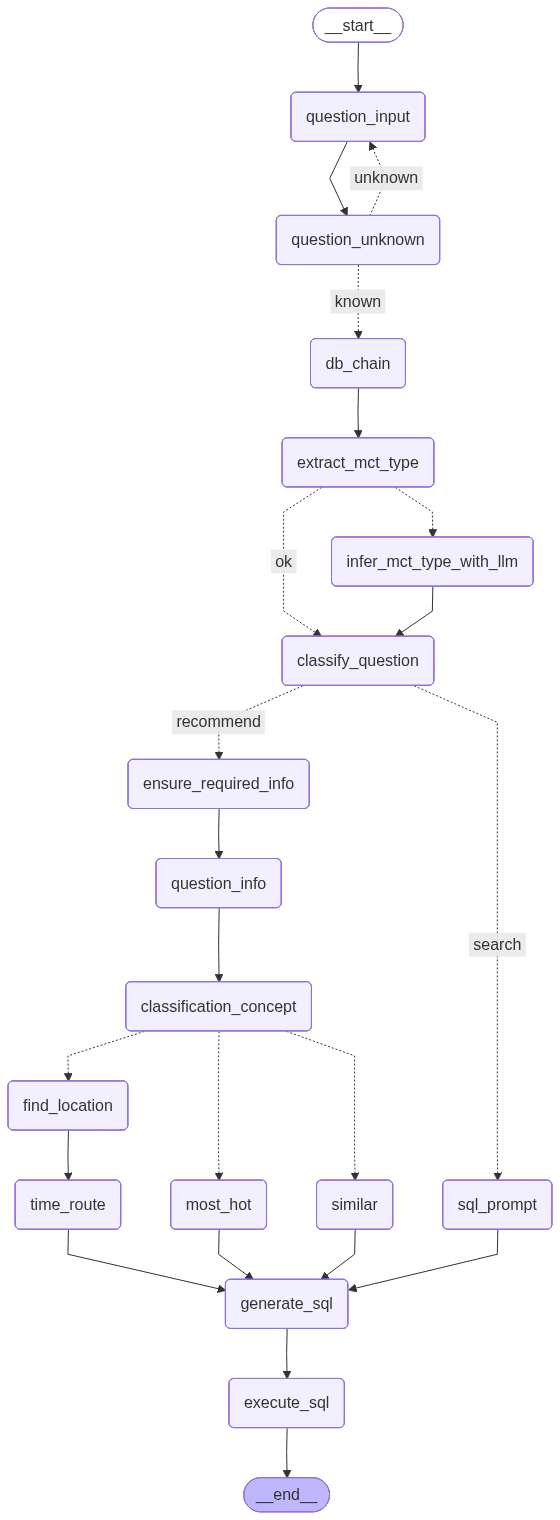

In [15]:
from IPython.display import Image, display

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass